In the previous example, we noticed the disbalance between false positives and false negatives in the LLM vs Human dataset. Let's repeat the experiment, but suppose we're only interested in spotting LLM-produced text. This is a natural parameter that we might want to tune: in some cases, we might not be worried about false positives as long as we catch all instances of LLM-produced text. In other cases, on the other hand, we are seriously worried about false positives. Think about plagiarism checking: we don't want to blame a student for using LLM to generate their essay unless we are very sure it is LLM-generated.

We'll start with the same preprocessing and use the Multinomial NB classifier.

In [3]:
import pandas as pd
df = pd.read_csv('human_vs_llm.csv.gz')
df

,text,source
0,The Mongol Empire was governed by a civilian a...,LLM
1,Tito woke up with a headache. He called in sic...,Human
2,@Holt \nThanks for taking time to give me so ...,Human
3,The appendix does have use. It has a role in m...,LLM
4,A giant panda in Hong Kong called Ying Ying is...,LLM
...,...,...
78277,Fire Protection in Commercial and Industrial B...,Human
78278,Restaurants aren't required to list ingredient...,LLM
78279,"In the United States, their persistent legal c...",Human
78280,"They will pay you a percentage for your time, ...",Human


In [4]:
SEED = 12345
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, random_state=SEED)
df_train.shape, df_test.shape

((58711, 2), (19571, 2))

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
X_train = cv.fit_transform(df_train['text'])
X_test = cv.transform(df_test['text'])
X_train.shape, X_test.shape

((58711, 186137), (19571, 186137))

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(df_train['source'])
y_test = le.transform(df_test['source'])
y_train.shape, y_test.shape

((58711,), (19571,))

In [7]:
from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB()
mnb.fit(X_train,y_train)

MultinomialNB()

We can predict the labels by choosing the class with higher probability as before.

In [8]:
y_predicted = mnb.predict(X_test)
y_predicted.shape

(19571,)

However, it will be more interesting to compute the probabilities of each class and not make a choice at this point.

In [9]:
p = mnb.predict_proba(X_test)
p.shape

(19571, 2)

Each row of the matrix has two values: the probability of each of the two classes.

If we choose the class that has the higher probability, we get the same classification result.

In [10]:
import numpy as np
all(np.argmax(p,axis=1) == y_predicted)

True

Let's decode the classes.

In [11]:
HUMAN_CLASS = 0 if le.classes_[0] == 'Human' else 1
LLM_CLASS = 1 - HUMAN_CLASS
HUMAN_CLASS, LLM_CLASS

(0, 1)

Let's see what the extrema for the probabilities look like.

In [12]:
p_min = np.min(p[:,LLM_CLASS])
p_max = np.max(p[:,LLM_CLASS])
p_min, p_max

(0.0, 1.0)

This is telling: because of the presence of words that do not occur in the other class, we are absolutely certain about the classification of some text excerpts.

Let's now iterate a threshold parameter *t* from 1 to 0 (or just slightly above 1 and slightly below 0 to account for these extrema) such that we classify anything as LLM-generated if the probability for that class is at least *t*. This creates a bunch of different observations with different numbers of true/false and positives/negatives each.

In [13]:
ts = np.linspace(1.001,-0.001,1000)
res = list()
for t in ts:
    y_pred = np.full(y_test.shape,HUMAN_CLASS)
    y_pred[p[:,LLM_CLASS] >= t] = LLM_CLASS
    tp = np.sum((y_pred == LLM_CLASS) & (y_test == LLM_CLASS))
    fp = np.sum((y_pred == LLM_CLASS) & (y_test == HUMAN_CLASS))
    tn = np.sum((y_pred == HUMAN_CLASS) & (y_test == HUMAN_CLASS))
    fn = np.sum((y_pred == HUMAN_CLASS) & (y_test == LLM_CLASS))
    res.append((tp,fp,tn,fn))
res = np.array(res)
res

array([[    0,     0,  8788, 10783],
       [ 6577,  1873,  6915,  4206],
       [ 7717,  2639,  6149,  3066],
       ...,
       [ 9980,  4252,  4536,   803],
       [10202,  4615,  4173,   581],
       [10783,  8788,     0,     0]])

We can see here that there are no true or false positives when *t* > 1: we always classify everything as human-generated. Likewise, when *t* < 0, we have no true/false negatives as we classify everything LLM-generated.

If we compute the true positive rate (tpr) and false positive rate (fpr), we can plot the Receiver-Operator Characteristic (ROC). We can then also plot the area under curve (AUC) which is commonly used as a measurement of the quality of the classifier.

Text(0.5, 1.0, 'ROC, AUC = 0.77')

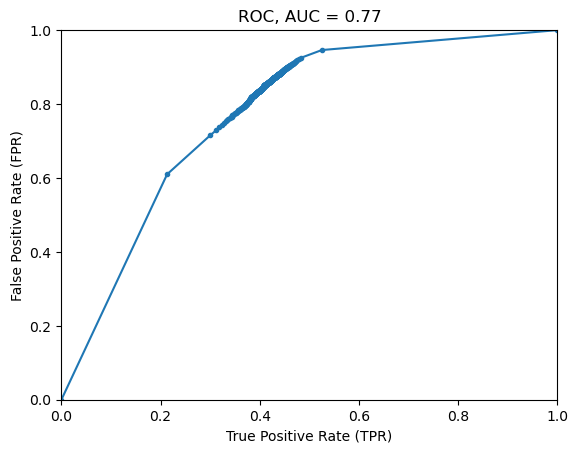

In [14]:
import matplotlib.pyplot as plt
tpr = res[:,0] / (res[:,0]+res[:,3])
fpr = res[:,1] / (res[:,1]+res[:,2])
plt.plot(fpr,tpr,marker='o',markersize=3)
plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel('True Positive Rate (TPR)')
plt.ylabel('False Positive Rate (FPR)')
auc = np.trapz(tpr,fpr)
plt.title(f'ROC, AUC = {auc:0.2f}')

The ROC looks a bit funny because the extrema lie so far away from other points; this is an artefact of the classifier that we use and the way it deals with zeros.

AUC is 0.79; not great, not terrible. It's certainly better than tossing a coin, but it's far from impressive. Then again, the methodology was rather basic.